In [1]:
import mujoco
import numpy as np
import types
import xml.etree.ElementTree as ET

model_path = "../leap_hand_model/right_hand.xml"
model = mujoco.MjModel.from_xml_path(model_path)

n_bodies = model.nbody
print("Number of bodies:", n_bodies)
print("Number of joints:", model.njnt)
parents = model.body_parentid  # shape (n_bodies,)
print("Body parent IDs:", parents)

try:
    sim = mujoco.MjSim(model)
except AttributeError:
    # Newer mujoco bindings use MjData; provide a lightweight sim-like wrapper
    data = mujoco.MjData(model)
    sim = types.SimpleNamespace(data=data)

# # 1) Bodies (XML order)
# tree = ET.parse(model_path)
# root = tree.getroot()
# bodies = [b.get("name") for b in root.findall(".//body") if b.get("name") is not None]
# print("Bodies (XML order):", bodies)

# # 2) Joints (XML order)
# joints = [j.get("name") for j in root.findall(".//joint") if j.get("name") is not None]
# print("Joints (XML order):", joints)

# # 5) Optional: print qpos slice per joint using model.jnt_qposadr to map qpos indices
# qpos = np.array(sim.data.qpos)
# nq = int(model.nq)
# qpos_addrs = np.array(model.jnt_qposadr, dtype=int)  # start address per joint
# print("\nJoint qpos values (from sim.data.qpos):")
# for jid, jname in enumerate(joints):
#     start = int(qpos_addrs[jid])
#     end = qpos_addrs[jid + 1] if (jid + 1) < len(qpos_addrs) else nq
#     vals = qpos[start:end]
#     print(jname, vals)


Number of bodies: 18
Number of joints: 16
Body parent IDs: [ 0  0  1  2  3  4  1  6  7  8  1 10 11 12  1 14 15 16]


In [2]:
import jax.numpy as jnp
num_nodes = model.njnt
print("Number of nodes (joints):", num_nodes)
hierarchy = model.jnt_bodyid  # shape (n_joints,)
parent_body_ids = model.body_parentid  # shape (n_bodies,)
print("Joint hierarchy (joint -> body):", hierarchy)
edges = jnp.array([[0,1],[1,2],[2,3],[4,5],[5,6],[6,7],[8,9],[9,10],[10,11],[12,13],[13,14],[14,15],[0,4],[4,8],[8,12]])  # shape (n_edges, 2)
senders = jnp.concatenate([edges[:, 0], edges[:,1]], axis=0)
print("Senders:", senders)
receivers = jnp.concatenate([edges[:, 1], edges[:,0]], axis=0)
print("Receivers:", receivers)

Number of nodes (joints): 16
Joint hierarchy (joint -> body): [ 2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17]
Senders: [ 0  1  2  4  5  6  8  9 10 12 13 14  0  4  8  1  2  3  5  6  7  9 10 11
 13 14 15  4  8 12]
Receivers: [ 1  2  3  5  6  7  9 10 11 13 14 15  4  8 12  0  1  2  4  5  6  8  9 10
 12 13 14  0  4  8]


# Training Process


In [3]:
import os
import gc
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"] = "platform"
os.environ["TF_GPU_ALLOCATOR"] = "cuda_malloc_async"
print('Setting environment variable to use GPU rendering:')
%env MUJOCO_GL=egl

try:
  print('Checking that the installation succeeded:')
  import mujoco

  mujoco.MjModel.from_xml_string('<mujoco/>')
except Exception as e:
  raise e from RuntimeError(
      'Something went wrong during installation. Check the shell output above '
      'for more information.\n'
      'If using a hosted Colab runtime, make sure you enable GPU acceleration '
      'by going to the Runtime menu and selecting "Choose runtime type".'
  )

print('Installation successful.')

# Tell XLA to use Triton GEMM, this improves steps/sec by ~30% on some GPUs
xla_flags = os.environ.get('XLA_FLAGS', '')
xla_flags += ' --xla_gpu_triton_gemm_any=True'
os.environ['XLA_FLAGS'] = xla_flags
import json
import itertools
import time
from typing import Callable, List, NamedTuple, Optional, Union
import numpy as np

# Graphics and plotting.

#!pip install -q mediapy
import mediapy as media
import matplotlib.pyplot as plt

# More legible printing from numpy.
np.set_printoptions(precision=3, suppress=True, linewidth=100)

Setting environment variable to use GPU rendering:
env: MUJOCO_GL=egl
Checking that the installation succeeded:
Installation successful.


In [4]:

from mujoco_playground import registry

env = registry.load("LeapCubeRotateZAxis")
mj_model = env.mj_model

print(mj_model.nbody)

for i in range(mj_model.nbody):
    print(
        i,
        mujoco.mj_id2name(
            mj_model,
            mujoco.mjtObj.mjOBJ_BODY,
            i,
        ),
        "parent:",
        mj_model.body_parentid[i],
    )


Warp 1.11.0 initialized:
   CUDA Toolkit 12.9, Driver 13.2
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA GeForce RTX 3060" (12 GiB, sm_86, mempool enabled)
   Kernel cache:
     /home/jonat/.cache/warp/1.11.0
Warp DeprecationWarning: The symbol `warp.types.warp_type_to_np_dtype` will soon be removed from the public API. It can still be accessed from `warp._src.types.warp_type_to_np_dtype` but might be changed or removed without notice.
21
0 world parent: 0
1 leap_mount parent: 0
2 palm parent: 1
3 if_bs parent: 2
4 if_px parent: 3
5 if_md parent: 4
6 if_ds parent: 5
7 mf_bs parent: 2
8 mf_px parent: 7
9 mf_md parent: 8
10 mf_ds parent: 9
11 rf_bs parent: 2
12 rf_px parent: 11
13 rf_md parent: 12
14 rf_ds parent: 13
15 th_mp parent: 2
16 th_bs parent: 15
17 th_px parent: 16
18 th_ds parent: 17
19 cube parent: 0
20 goal parent: 0


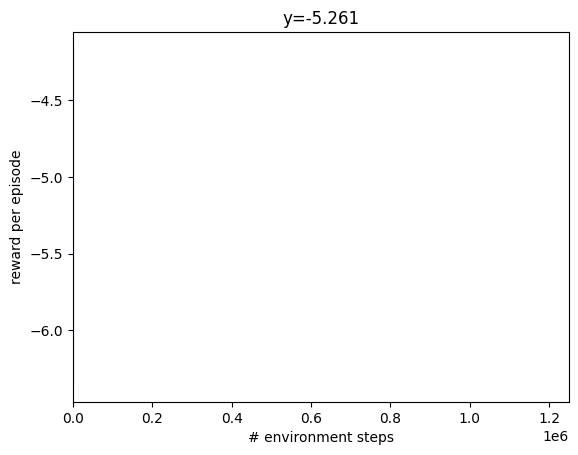

progress: 0
{'eval/walltime': 18.647051334381104, 'eval/episode_reward': np.float32(-5.2605333), 'eval/episode_reward/action_rate': np.float32(0.0), 'eval/episode_reward/angvel': np.float32(-7.554413), 'eval/episode_reward/energy': np.float32(0.0), 'eval/episode_reward/linvel': np.float32(0.0), 'eval/episode_reward/pose': np.float32(0.0), 'eval/episode_reward/termination': np.float32(-97.65625), 'eval/episode_reward/torques': np.float32(0.0), 'eval/episode_reward_std': np.float32(1.0966617), 'eval/episode_reward/action_rate_std': np.float32(0.0), 'eval/episode_reward/angvel_std': np.float32(14.833251), 'eval/episode_reward/energy_std': np.float32(0.0), 'eval/episode_reward/linvel_std': np.float32(0.0), 'eval/episode_reward/pose_std': np.float32(0.0), 'eval/episode_reward/termination_std': np.float32(15.128841), 'eval/episode_reward/torques_std': np.float32(0.0), 'eval/avg_episode_length': np.float32(93.9375), 'eval/std_episode_length': np.float32(91.45676), 'eval/epoch_eval_time': 18.6

2026-06-28 15:22:30.389180: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-06-28 15:22:30.389503: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-06-28 15:22:30.389688: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-06-28 15:22:30.389707: W external/xla/xla/service/gpu/au

In [ ]:
# @title Import MuJoCo, MJX, and Brax
from datetime import datetime
import functools
import os
from typing import Any, Dict, Sequence, Tuple, Union
from brax import base
from brax import envs
from brax import math
from brax.base import Base, Motion, Transform
from brax.base import State as PipelineState
from brax.envs.base import Env, PipelineEnv, State
from brax.io import html, mjcf, model
from brax.mjx.base import State as MjxState
import network_brax as networks_brax
import ppo_networks_gnn as ppo_networks
from gnn_implementation import train as ppo

from etils import epath
from flax import struct
from flax.training import orbax_utils
from IPython.display import HTML, clear_output
import jax
from jax import numpy as jp
from matplotlib import pyplot as plt
import mediapy as media
from ml_collections import config_dict
import mujoco
from mujoco import mjx
import numpy as np
from orbax import checkpoint as ocp
from mujoco_playground import wrapper
from mujoco_playground import registry
from mujoco_playground.config import manipulation_params


env_name = 'LeapCubeRotateZAxis'
env = registry.load(env_name)
env_cfg = registry.get_default_config(env_name)
print("Observation size:", env.observation_size, "Action size:", env.action_size)

print(jax.devices())
ppo_params = manipulation_params.brax_ppo_config(env_name)
ppo_params["num_timesteps"] = 1000000
ppo_params["num_envs"] = 4
ppo_params["num_evals"] = 16


x_data, y_data, y_dataerr = [], [], []
times = [datetime.now()]

def progress(num_steps, metrics):
  clear_output(wait=True)

  times.append(datetime.now())
  x_data.append(num_steps)
  y_data.append(metrics["eval/episode_reward"])
  y_dataerr.append(metrics["eval/episode_reward_std"])

  plt.xlim([0, ppo_params["num_timesteps"] * 1.25])
  plt.xlabel("# environment steps")
  plt.ylabel("reward per episode")
  plt.title(f"y={y_data[-1]:.3f}")
  plt.errorbar(x_data, y_data, yerr=y_dataerr, color="blue")

  display(plt.gcf())
  print("progress:", num_steps)
  print(metrics)

ppo_training_params = dict(ppo_params)
#print("action size:", ppo_training_params["action_size"])


abd = networks_brax.ABDNet(
    layer_sizes=[32],
    hidden_dim=64,
    num_nodes=17,
    node_feature_dim=2,
)

params = abd.init(
    jax.random.PRNGKey(0),
    jnp.zeros((1,32))
)

out = abd.apply(
    params,
    jnp.zeros((1,32))
)

print(out.shape)

network_factory = ppo_networks.make_ppo_networks
if "network_factory" in ppo_params:
  del ppo_training_params["network_factory"]
  network_factory = functools.partial(
      ppo_networks.make_ppo_networks,
      **ppo_params.network_factory
  )

train_fn = functools.partial(
    ppo.train, **dict(ppo_training_params),
    network_factory=network_factory,
    progress_fn=progress,
    seed=1
)

make_inference_fn, params, metrics = train_fn(
    environment=env,
    wrap_env_fn=wrapper.wrap_for_brax_training,
)
print(f"time to jit: {times[1] - times[0]}")
print(f"time to train: {times[-1] - times[1]}")